In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/soumyadebmukherjee/heart-and-lung-sounds-dataset/HLS-CMDS Heart and Lung Sounds Dataset Recorded from a Clinical Manikin using Digital Stethoscope/Mix.csv
/kaggle/input/datasets/soumyadebmukherjee/heart-and-lung-sounds-dataset/HLS-CMDS Heart and Lung Sounds Dataset Recorded from a Clinical Manikin using Digital Stethoscope/LS.csv
/kaggle/input/datasets/soumyadebmukherjee/heart-and-lung-sounds-dataset/HLS-CMDS Heart and Lung Sounds Dataset Recorded from a Clinical Manikin using Digital Stethoscope/HS.csv
/kaggle/input/datasets/soumyadebmukherjee/heart-and-lung-sounds-dataset/HLS-CMDS Heart and Lung Sounds Dataset Recorded from a Clinical Manikin using Digital Stethoscope/Mix/Mix/M0115.wav
/kaggle/input/datasets/soumyadebmukherjee/heart-and-lung-sounds-dataset/HLS-CMDS Heart and Lung Sounds Dataset Recorded from a Clinical Manikin using Digital Stethoscope/Mix/Mix/H0104.wav
/kaggle/input/datasets/soumyadebmukherjee/heart-and-lung-sounds-dataset/HLS-CMDS Heart and L

In [2]:
!pip install matplotlib
!pip install --upgrade librosa

In [3]:
import os
import numpy as np
import pandas as pd
import librosa
base_path="/kaggle/input/datasets/soumyadebmukherjee/heart-and-lung-sounds-dataset/HLS-CMDS Heart and Lung Sounds Dataset Recorded from a Clinical Manikin using Digital Stethoscope"
mix_path=base_path+"/Mix/Mix"
files=os.listdir(mix_path)
print("Total files:",len(files))
print(files[:10])

Total files: 436
['M0115.wav', 'H0104.wav', 'H0013.wav', 'L0070.wav', 'H0017.wav', 'L0024.wav', 'M0109.wav', 'H0109.wav', 'H0002.wav', 'H0108.wav']


In [4]:
import librosa
file_path=mix_path+'/'+files[0]
y,sr=librosa.load(file_path,sr=None)
print("Shape:",y.shape)
print("Sample rate:",sr)

Shape: (60000,)
Sample rate: 4000


In [5]:
import IPython.display as ipd
ipd.Audio(file_path)

In [6]:
import pandas as pd
df=pd.read_csv(base_path+"/Mix.csv")
df.head

<bound method NDFrame.head of     Gender       Heart Sound Type  Lung Sound Type Location Heart Sound ID  \
0        F   Late Systolic Murmur          Rhonchi     LUSB          H0001   
1        F                     S3           Normal      RLA          H0002   
2        M    Atrial Fibrillation           Normal      LMA          H0003   
3        F                     S3  Coarse Crackles     Apex          H0004   
4        M               AV Block    Fine Crackles     RUSB          H0005   
..     ...                    ...              ...      ...            ...   
140      M                     S4         Wheezing     Apex          H0141   
141      F    Mid Systolic Murmur           Normal      RMA          H0142   
142      F  Early Systolic Murmur         Wheezing      RLA          H0143   
143      F               AV Block           Normal      LUA          H0144   
144      M  Late Diastolic Murmur           Normal     RUSB          H0145   

    Lung Sound ID Mixed Sound ID 

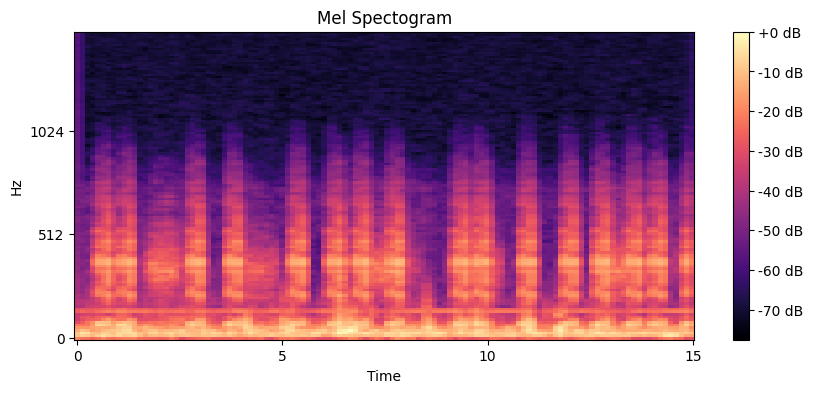

In [7]:

import librosa
import librosa.display
import matplotlib.pyplot as plt
from librosa.feature import melspectrogram
import numpy as np
import os

file_path= mix_path+"/"+files[0] #loading audio
y,sr=librosa.load(file_path,sr=None)
mel_spec = melspectrogram(y=y, sr=sr, n_mels=128)
mel_spec_db=librosa.power_to_db(mel_spec,ref=np.max)
plt.figure(figsize=(10,4))
librosa.display.specshow(mel_spec_db,sr=sr,x_axis='time',y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectogram")
plt.show()


In [8]:
df = pd.read_csv(base_path + "/Mix.csv")

# clean columns (important)
df.columns = df.columns.str.strip()

print(df.head())
print(df.columns)

  Gender      Heart Sound Type  Lung Sound Type Location Heart Sound ID  \
0      F  Late Systolic Murmur          Rhonchi     LUSB          H0001   
1      F                    S3           Normal      RLA          H0002   
2      M   Atrial Fibrillation           Normal      LMA          H0003   
3      F                    S3  Coarse Crackles     Apex          H0004   
4      M              AV Block    Fine Crackles     RUSB          H0005   

  Lung Sound ID Mixed Sound ID  
0         L0001          M0001  
1         L0002          M0002  
2         L0003          M0003  
3         L0004          M0004  
4         L0005          M0005  
Index(['Gender', 'Heart Sound Type', 'Lung Sound Type', 'Location',
       'Heart Sound ID', 'Lung Sound ID', 'Mixed Sound ID'],
      dtype='object')


In [9]:
df['file_name'] = df['Mixed Sound ID']+".wav"

# check
print(df[['Mixed Sound ID', 'file_name', 'Lung Sound Type']].head())

  Mixed Sound ID  file_name  Lung Sound Type
0          M0001  M0001.wav          Rhonchi
1          M0002  M0002.wav           Normal
2          M0003  M0003.wav           Normal
3          M0004  M0004.wav  Coarse Crackles
4          M0005  M0005.wav    Fine Crackles


This project classifies lung diseases using audio recordings.
We convert audio signals into MFCC features and train a machine learning model to predict disease types.

In [10]:
X = []
y = []

for i in range(len(df)):
    try:
        file = df['file_name'][i]
        file_path = os.path.join(mix_path, file)

        # load audio
        audio, sr = librosa.load(file_path, sr=None)

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        mfcc_mean = np.mean(mfcc, axis=1)

        X.append(mfcc_mean)
        y.append(df['Lung Sound Type'][i])

    except Exception as e:
        print("Error:", e)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (145, 40)
y shape: (145,)


In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_encoded=le.fit_transform(y)
print(le.classes_)



['Coarse Crackles' 'Fine Crackles' 'Normal' 'Pleural Rub' 'Rhonchi'
 'Wheezing']


In [12]:
X_flat=X.reshape(X.shape[0],-1)
print("Shape after flatten:", X_flat.shape)
#training

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train,X_test,y_train,y_test=train_test_split(
    X_flat,y_encoded,test_size=0.2,random_state=42
)
model=RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train)
accuracy=model.score(X_test,y_test)

Shape after flatten: (145, 40)


In [13]:
print("Accuracy:",accuracy)

Accuracy: 0.4827586206896552


In [14]:
pred = model.predict(X_test)

pred_labels = le.inverse_transform(pred)
actual_labels = le.inverse_transform(y_test)

for i in range(10):
    print("Pred:", pred_labels[i], "| Actual:", actual_labels[i])

Pred: Normal | Actual: Normal
Pred: Wheezing | Actual: Wheezing
Pred: Coarse Crackles | Actual: Coarse Crackles
Pred: Pleural Rub | Actual: Normal
Pred: Fine Crackles | Actual: Pleural Rub
Pred: Fine Crackles | Actual: Fine Crackles
Pred: Wheezing | Actual: Wheezing
Pred: Fine Crackles | Actual: Fine Crackles
Pred: Rhonchi | Actual: Rhonchi
Pred: Rhonchi | Actual: Pleural Rub


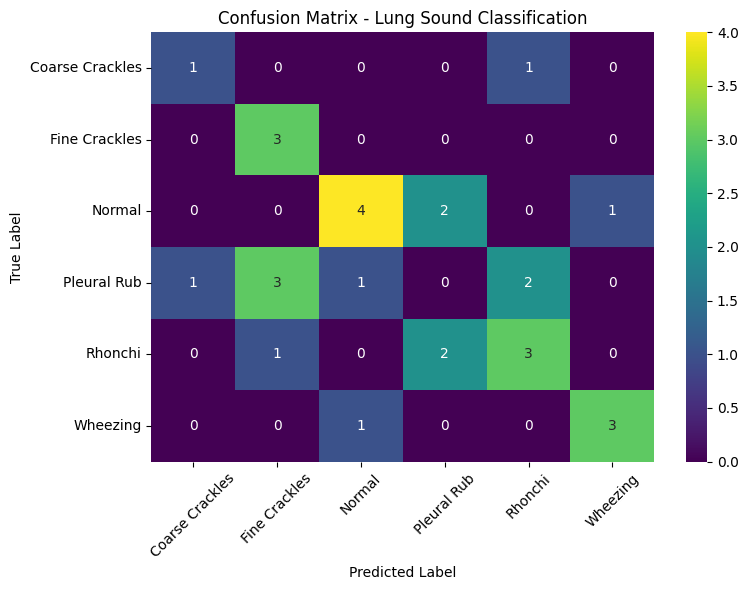

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# compute confusion matrix
cm = confusion_matrix(y_test, pred)

# plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='viridis',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Lung Sound Classification")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()